# Tabular Preprocessing
See *patient_data_instructions.md* for dataset info

In [1]:
import pandas as pd
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("initial_data_cleaning").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/29 00:51:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/04/29 00:51:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## Cleaning/Combining datasets based on datatype

In [2]:
from functools import reduce
from pyspark.sql import DataFrame

### Datatype: Demographic Data (DEMO)

In [3]:
# Locations
demo_l_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/DEMO_L.csv"
demo_p_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/P_DEMO.csv"
demo_i_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/DEMO_I.csv"
demo_h_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/DEMO_H.csv"

# Readings
demo_l = spark.read.csv(demo_l_location, inferSchema = True, header = True)
demo_p = spark.read.csv(demo_p_location, inferSchema = True, header = True)
demo_i = spark.read.csv(demo_i_location, inferSchema = True, header = True)
demo_h = spark.read.csv(demo_h_location, inferSchema = True, header = True)

# Place into array
demos = [demo_l, demo_p, demo_i, demo_h]

25/04/29 00:52:05 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
                                                                                

In [4]:
# Selecting only important columns
demo_cols = ['SEQN', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH3']
demo_cols_renamed = ['SEQN', 'Gender', 'Age', 'Race']

for i in range(len(demos)):
    demos[i] = demos[i].select(demo_cols).toDF(*demo_cols_renamed)

In [5]:
demo_l = demos[0]
demo_p = demos[1]
demo_i = demos[2]
demo_h = demos[3]

In [6]:
demo_l.describe().show()

25/04/29 00:52:24 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 10:>                                                         (0 + 1) / 1]

+-------+----------------+-------------------+--------------------+------------------+
|summary|            SEQN|             Gender|                 Age|              Race|
+-------+----------------+-------------------+--------------------+------------------+
|  count|           11933|              11933|               11933|             11933|
|   mean|        136344.0| 1.5328081789994135|  38.317858040727394|3.3205396798793263|
| stddev|3444.90471566341|0.49894336877363876|   25.60199011389116|1.5183792913880416|
|    min|        130378.0|                1.0|5.397605346934028...|               1.0|
|    max|        142310.0|                2.0|                80.0|               7.0|
+-------+----------------+-------------------+--------------------+------------------+



In [7]:
demo = reduce(DataFrame.unionByName, demos)
demo.describe().show()

[Stage 11:===========================================>              (3 + 1) / 4]

+-------+------------------+------------------+------------------+-----------------+
|summary|              SEQN|            Gender|               Age|             Race|
+-------+------------------+------------------+------------------+-----------------+
|  count|             47639|             47639|             47639|            47639|
|   mean|107747.31121560067|1.5131929721446713| 34.02044543336342|3.345578202733055|
| stddev|22425.859947651064|0.4998311612371023|25.225247534762826|1.610803520358708|
|    min|           73557.0|               1.0|               0.0|              1.0|
|    max|          142310.0|               2.0|              80.0|              7.0|
+-------+------------------+------------------+------------------+-----------------+



### Datatype: Body Measures Data (BMX)

In [8]:
# Locations
bmx_l_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/BMX_L.csv"
bmx_p_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/P_BMX.csv"
bmx_i_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/BMX_I.csv"
bmx_h_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/BMX_H.csv"

# Readings
bmx_l = spark.read.csv(bmx_l_location, inferSchema = True, header = True)
bmx_p = spark.read.csv(bmx_p_location, inferSchema = True, header = True)
bmx_i = spark.read.csv(bmx_i_location, inferSchema = True, header = True)
bmx_h = spark.read.csv(bmx_h_location, inferSchema = True, header = True)

# Place into array
bmxs = [bmx_l, bmx_p, bmx_i, bmx_h]

In [9]:
# Selecting only important columns
bmx_cols = ['SEQN', 'BMXWT', 'BMXHT', 'BMXBMI']
bmx_cols_renamed = ['SEQN', 'Weight', 'Height', 'BMI']

for i in range(len(bmxs)):
    bmxs[i] = bmxs[i].select(bmx_cols).toDF(*bmx_cols_renamed)

In [10]:
bmx = reduce(DataFrame.unionByName, bmxs)
bmx.describe().show()

[Stage 22:===========================================>              (3 + 1) / 4]

+-------+------------------+-----------------+------------------+-----------------+
|summary|              SEQN|           Weight|            Height|              BMI|
+-------+------------------+-----------------+------------------+-----------------+
|  count|             42517|            41997|             39492|            39419|
|   mean|105853.76383564221|65.17391647022393|156.72114453560212|26.41660620512948|
| stddev|22045.230400110828|32.42806546949411|22.334302867742647|8.173481052809024|
|    min|           73557.0|              2.7|              78.3|             11.1|
|    max|          142310.0|            254.3|             202.7|             92.3|
+-------+------------------+-----------------+------------------+-----------------+



### Datatype: Smoking Data (SMQ)

In [11]:
# Locations
smq_l_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/SMQ_L.csv"
smq_p_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/P_SMQ.csv"
smq_i_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/SMQ_I.csv"
smq_h_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/SMQ_H.csv"

# Readings
smq_l = spark.read.csv(smq_l_location, inferSchema = True, header = True)
smq_p = spark.read.csv(smq_p_location, inferSchema = True, header = True)
smq_i = spark.read.csv(smq_i_location, inferSchema = True, header = True)
smq_h = spark.read.csv(smq_h_location, inferSchema = True, header = True)

# Place into array
smqs = [smq_l, smq_p, smq_i, smq_h]

In [12]:
# Selecting only important columns
smq_cols = ['SEQN', 'SMQ020']
smq_cols_renamed = ['SEQN', 'Smokes?']

for i in range(len(smqs)):
    smqs[i] = smqs[i].select(smq_cols).toDF(*smq_cols_renamed)

In [13]:
smq = reduce(DataFrame.unionByName, smqs)
smq.describe().show()

[Stage 33:=============================>                            (2 + 2) / 4]

+-------+------------------+------------------+
|summary|              SEQN|           Smokes?|
+-------+------------------+------------------+
|  count|             34321|             29933|
|   mean|108332.39037324088|1.6014098152540674|
| stddev| 22504.19959085665|0.5385518575097396|
|    min|           73557.0|               1.0|
|    max|          142310.0|               9.0|
+-------+------------------+------------------+



### Datatype: Alcohol Data (ALQ)

In [14]:
# Locations
alq_l_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/ALQ_L.csv"
alq_p_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/P_ALQ.csv"
alq_i_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/ALQ_I.csv"
alq_h_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/ALQ_H.csv"

# Readings
alq_l = spark.read.csv(alq_l_location, inferSchema = True, header = True)
alq_p = spark.read.csv(alq_p_location, inferSchema = True, header = True)
alq_i = spark.read.csv(alq_i_location, inferSchema = True, header = True)
alq_h = spark.read.csv(alq_h_location, inferSchema = True, header = True)

# Place into array
alqs = [alq_l, alq_p, alq_i, alq_h]

In [15]:
# Selecting only important columns
alq_cols = ['SEQN', 'ALQ130']
alq_cols_renamed = ['SEQN', 'Alcohol/Day']

for i in range(len(alqs)):
    alqs[i] = alqs[i].select(alq_cols).toDF(*alq_cols_renamed)

In [16]:
alq = reduce(DataFrame.unionByName, alqs)
alq.describe().show()

+-------+------------------+------------------+
|summary|              SEQN|       Alcohol/Day|
+-------+------------------+------------------+
|  count|             26961|             16907|
|   mean|107138.44972367494| 4.387058614774945|
| stddev|22299.379681709317|41.304098767179724|
|    min|           73557.0|               1.0|
|    max|          142310.0|             999.0|
+-------+------------------+------------------+



### Datatype: Medical Data (MCQ)

In [17]:
# Locations
mcq_l_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/MCQ_L.csv"
mcq_p_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/P_MCQ.csv"
mcq_i_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/MCQ_I.csv"
mcq_h_location = "hdfs://localhost:9000/user/jj/final_proj/csv_files/MCQ_H.csv"

# Readings
mcq_l = spark.read.csv(mcq_l_location, inferSchema = True, header = True)
mcq_p = spark.read.csv(mcq_p_location, inferSchema = True, header = True)
mcq_i = spark.read.csv(mcq_i_location, inferSchema = True, header = True)
mcq_h = spark.read.csv(mcq_h_location, inferSchema = True, header = True)

# Place into array
mcqs = [mcq_l, mcq_p, mcq_i, mcq_h]

In [18]:
# Selecting only important columns
mcq_cols = ['SEQN', 'MCQ220', 'MCQ160b', 'MCQ160c', 'MCQ160e', 'MCQ160f', 'MCQ160m']
mcq_cols_renamed = ['SEQN', 'Cancer', 'Congestive Heart Failure', 'Coronary Heart Disease', 'Heart Attack', 'Stroke', 'Thyroid']

for i in range(len(mcqs)):
    mcqs[i] = mcqs[i].select(mcq_cols).toDF(*mcq_cols_renamed)

In [19]:
mcq = reduce(DataFrame.unionByName, mcqs)
mcq.describe().show()

+-------+------------------+------------------+------------------------+----------------------+------------------+------------------+------------------+
|summary|              SEQN|            Cancer|Congestive Heart Failure|Coronary Heart Disease|      Heart Attack|            Stroke|           Thyroid|
+-------+------------------+------------------+------------------------+----------------------+------------------+------------------+------------------+
|  count|             46075|             28527|                   28528|                 28527|             28527|             28526|             28526|
|   mean|107941.54632664134|1.8891225856206402|       1.975918395961862|    1.9804045290426613|1.9659270165106741|1.9671878286475497|1.8971114071373485|
| stddev|22461.008710253085|0.3580141235765636|      0.3732594332108305|    0.4767630715803518|0.3308699173333608|0.3521456857118053|0.4575215010516573|
|    min|           73557.0|               1.0|                     1.0|          

## Combining all datatypes to make one dataframe

In [20]:
df = demo
df = df.join(bmx, on='SEQN', how='left')
df = df.join(smq, on='SEQN', how='left')
df = df.join(alq, on='SEQN', how='left')
df = df.join(mcq, on='SEQN', how='left')

In [21]:
df.describe().show()

[Stage 64:>                                                         (0 + 1) / 1]

+-------+------------------+------------------+------------------+-----------------+-----------------+------------------+-----------------+------------------+------------------+------------------+------------------------+----------------------+------------------+------------------+------------------+
|summary|              SEQN|            Gender|               Age|             Race|           Weight|            Height|              BMI|           Smokes?|       Alcohol/Day|            Cancer|Congestive Heart Failure|Coronary Heart Disease|      Heart Attack|            Stroke|           Thyroid|
+-------+------------------+------------------+------------------+-----------------+-----------------+------------------+-----------------+------------------+------------------+------------------+------------------------+----------------------+------------------+------------------+------------------+
|  count|             47639|             47639|             47639|            47639|          

In [22]:
df.show(5)

+--------+------+----+----+------+------+----+-------+-----------+------+------------------------+----------------------+------------+------+-------+
|    SEQN|Gender| Age|Race|Weight|Height| BMI|Smokes?|Alcohol/Day|Cancer|Congestive Heart Failure|Coronary Heart Disease|Heart Attack|Stroke|Thyroid|
+--------+------+----+----+------+------+----+-------+-----------+------+------------------------+----------------------+------------+------+-------+
|130378.0|   1.0|43.0| 6.0|  86.9| 179.5|27.0|    1.0|       NULL|   2.0|                     2.0|                   2.0|         2.0|   2.0|    2.0|
|130379.0|   1.0|66.0| 3.0| 101.8| 174.2|33.5|    1.0|        3.0|   1.0|                     2.0|                   2.0|         2.0|   2.0|    2.0|
|130380.0|   2.0|44.0| 2.0|  69.4| 152.9|29.7|    2.0|        1.0|   2.0|                     2.0|                   2.0|         2.0|   2.0|    1.0|
|130381.0|   2.0| 5.0| 7.0|  34.3| 120.1|23.8|   NULL|       NULL|  NULL|                    NULL|  

In [23]:
df.select('Race').distinct().show()

[Stage 70:===========================================>              (3 + 1) / 4]

+----+
|Race|
+----+
| 7.0|
| 1.0|
| 4.0|
| 3.0|
| 2.0|
| 6.0|
+----+



In [24]:
df.printSchema()

root
 |-- SEQN: double (nullable = true)
 |-- Gender: double (nullable = true)
 |-- Age: double (nullable = true)
 |-- Race: double (nullable = true)
 |-- Weight: double (nullable = true)
 |-- Height: double (nullable = true)
 |-- BMI: double (nullable = true)
 |-- Smokes?: double (nullable = true)
 |-- Alcohol/Day: double (nullable = true)
 |-- Cancer: double (nullable = true)
 |-- Congestive Heart Failure: double (nullable = true)
 |-- Coronary Heart Disease: double (nullable = true)
 |-- Heart Attack: double (nullable = true)
 |-- Stroke: double (nullable = true)
 |-- Thyroid: double (nullable = true)



In [ ]:
# 1 --> Mexican American
# 2 --> Other Hispanic
# 3 --> Non-Hispanic White
# 4 --> Non-Hispanic Black
# 6 --> Non-Hispanic Asian
# 7 --> Other/Multi

## EDA

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, sum

### Datatype: Demographic Data (DEMO)

In [24]:
# Null Check
null_counts = demo.select([
    sum(col(c).isNull().cast("int")).alias(c) for c in demo.columns
])

null_counts.show()


[Stage 70:=============================>                            (2 + 2) / 4]

+----+------+---+----+
|SEQN|Gender|Age|Race|
+----+------+---+----+
|   0|     0|  0|   0|
+----+------+---+----+



In [25]:
demo_pd = demo.sample(fraction=0.25, seed=101).toPandas()

In [26]:
demo_pd.head()

,SEQN,Gender,Age,Race
0,130384.0,1.0,43.0,1.0
1,130386.0,1.0,34.0,1.0
2,130388.0,2.0,27.0,4.0
3,130390.0,2.0,31.0,3.0
4,130394.0,1.0,51.0,3.0


<Axes: xlabel='Gender', ylabel='count'>

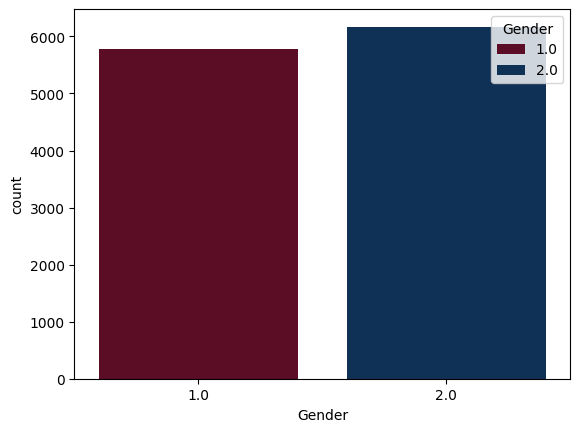

In [27]:
sns.countplot(data=demo_pd, x='Gender', hue='Gender', palette='RdBu')
# plt.savefig('gender_countplot.png', dpi=300, bbox_inches='tight')

*Observation:* Gender is evenly distributed

<Axes: xlabel='Age', ylabel='Count'>

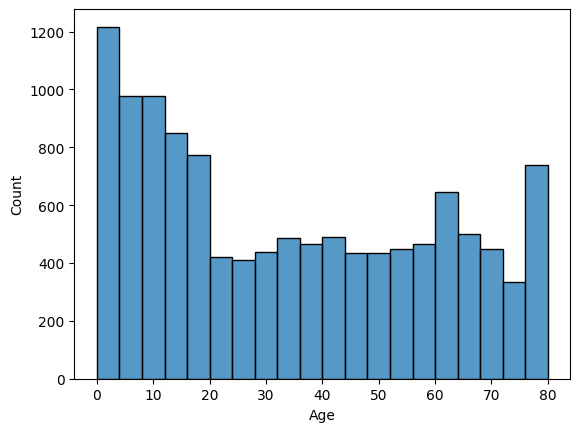

In [28]:
sns.histplot(data=demo_pd, x='Age')
# plt.savefig('age_histplot.png', dpi=300, bbox_inches='tight')

*Observation:* Age is not evenly distributed<br>
*TODO:* Resample age

<Axes: xlabel='Race', ylabel='count'>

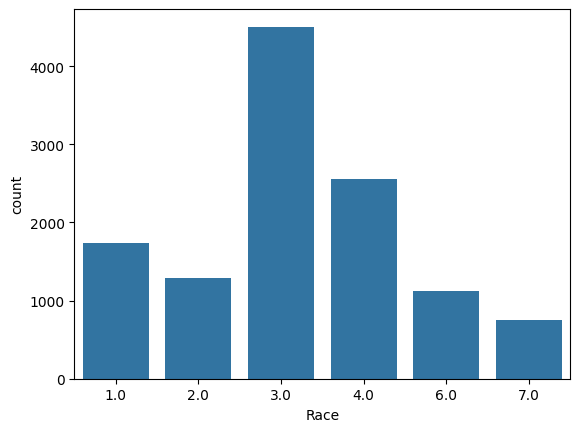

In [29]:
sns.countplot(data=demo_pd, x='Race')
# plt.savefig('race_countplot.png', dpi=300, bbox_inches='tight')

*Observation:* Dataset mainly contains "Non-Hispanic White"

### Datatype: Body Measures Data (BMX)

In [30]:
null_counts = bmx.select([
    sum(col(c).isNull().cast("int")).alias(c) for c in bmx.columns
])

null_counts.show()

+----+------+------+----+
|SEQN|Weight|Height| BMI|
+----+------+------+----+
|   0|   520|  3025|3098|
+----+------+------+----+



*Observation:* A lot of nulls in BMI<BR>
*TODO:* Consider dropping all BMI nulls and only using BMI column

In [31]:
bmx_pd = bmx.sample(fraction=0.25, seed=101).toPandas()

In [32]:
bmx_pd.head()

,SEQN,Weight,Height,BMI
0,130387.0,103.5,155.9,42.6
1,130389.0,79.8,168.9,28.0
2,130391.0,116.3,172.8,38.9
3,130393.0,142.0,175.6,46.1
4,130397.0,130.2,161.8,49.7


<Axes: xlabel='Weight', ylabel='Count'>

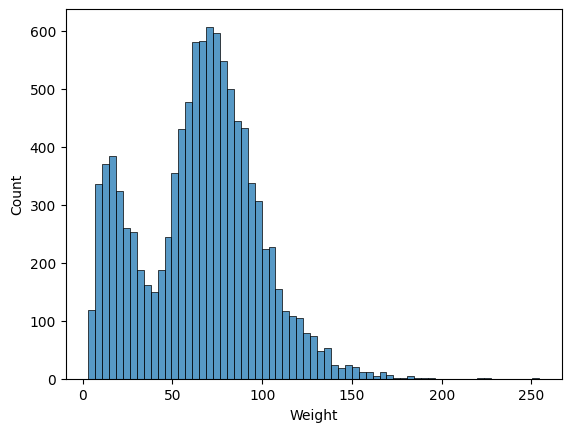

In [33]:
sns.histplot(data=bmx_pd, x='Weight')
# plt.savefig('weight_histplot.png', dpi=300, bbox_inches='tight')

<Axes: xlabel='Height', ylabel='Count'>

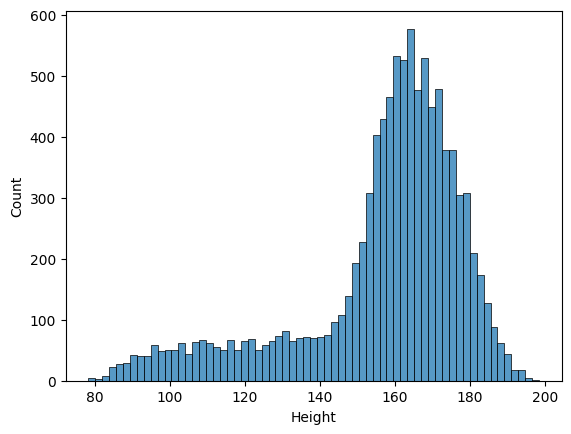

In [34]:
sns.histplot(data=bmx_pd, x='Height')
# plt.savefig('height_histplot.png', dpi=300, bbox_inches='tight')

<Axes: xlabel='BMI', ylabel='Count'>

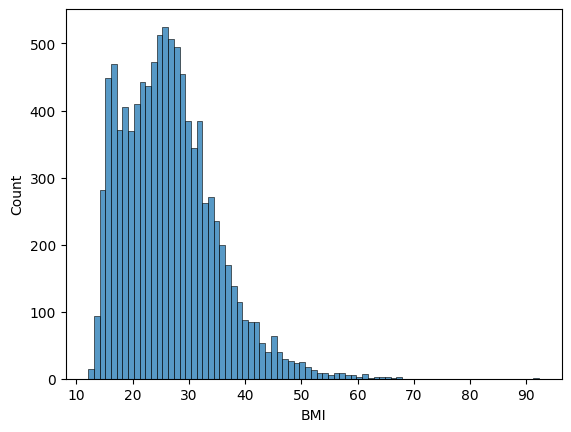

In [35]:
sns.histplot(data=bmx_pd, x='BMI')
# plt.savefig('bmi_histplot.png', dpi=300, bbox_inches='tight')

*Observation:* BMI shows the best distribution out of the metrics selected<br>
*TODO:* Filter to only use BMI

### Datatype: Smoking Data (SMQ)

In [36]:
null_counts = smq.select([
    sum(col(c).isNull().cast("int")).alias(c) for c in smq.columns
])

null_counts.show()

+----+-------+
|SEQN|Smokes?|
+----+-------+
|   0|   4388|
+----+-------+



*Observation:* Good amount of nulls + this dataset is already smaller<br>
*TODO:* Consider imputing based on age? Look further into when combined

In [37]:
smq_pd = smq.sample(fraction=0.25, seed=101).toPandas()

In [38]:
smq_pd.head()

,SEQN,Smokes?
0,130387.0,2.0
1,130389.0,1.0
2,130391.0,1.0
3,130393.0,2.0
4,130397.0,2.0


<Axes: xlabel='Smokes?', ylabel='count'>

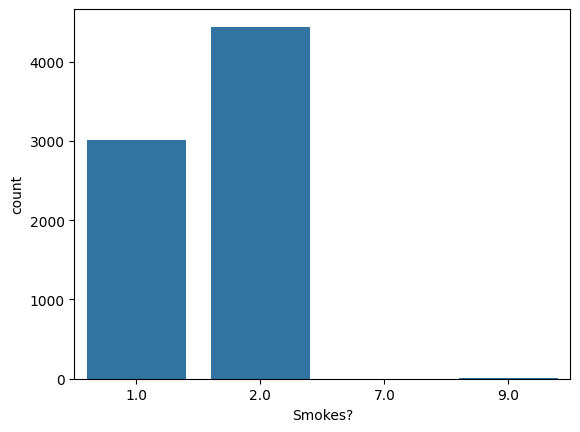

In [39]:
sns.countplot(data=smq_pd, x='Smokes?')
# plt.savefig('smokes_countplot.png', dpi=300, bbox_inches='tight')

### Datatype: Alcohol Data (ALQ)

In [40]:
null_counts = alq.select([
    sum(col(c).isNull().cast("int")).alias(c) for c in alq.columns
])

null_counts.show()

+----+-----------+
|SEQN|Alcohol/Day|
+----+-----------+
|   0|      10054|
+----+-----------+



*Observation:* A lot of nulls -> safe to assume nulls are 0 or close to it?

In [41]:
alq_pd = alq.sample(fraction=0.25, seed=101).toPandas()

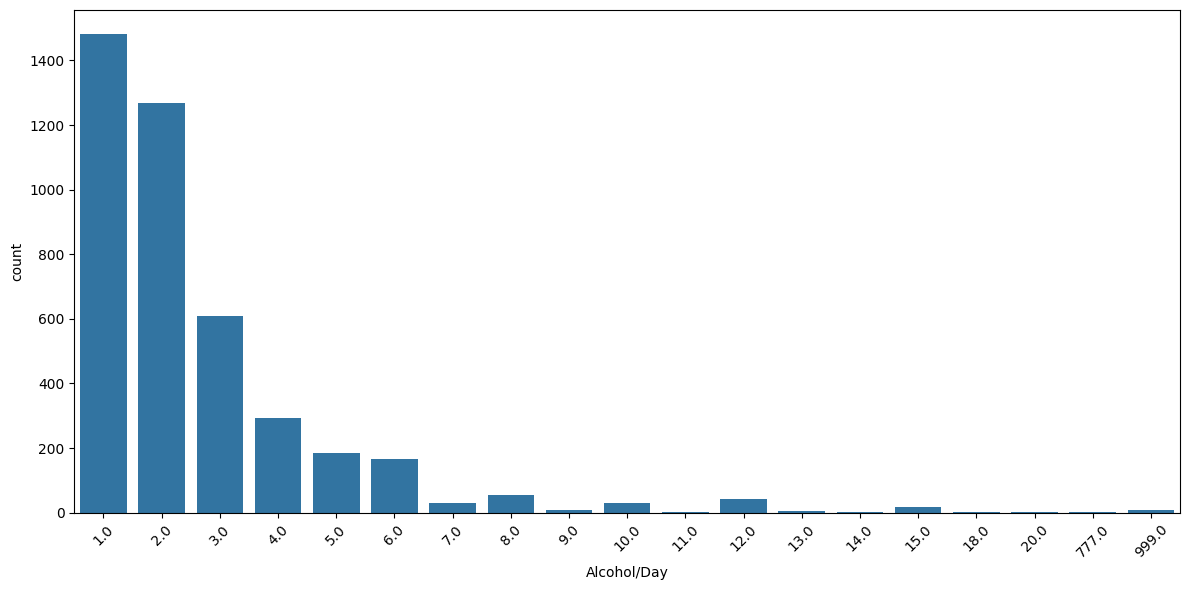

In [42]:
plt.figure(figsize=(12, 6))
sns.countplot(data=alq_pd, x='Alcohol/Day')

plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('alcohol_countplot.png', dpi=300, bbox_inches='tight')
plt.show()

*Observation:* 777 and 999 are codes<br>
*TODO:* Remove or impute them + nulls

### Datatype: Medical Data (MCQ)

In [43]:
null_counts = mcq.select([
    sum(col(c).isNull().cast("int")).alias(c) for c in mcq.columns
])

null_counts.show()

[Stage 86:=============================>                            (2 + 2) / 4]

+----+------+------------------------+----------------------+------------+------+-------+
|SEQN|Cancer|Congestive Heart Failure|Coronary Heart Disease|Heart Attack|Stroke|Thyroid|
+----+------+------------------------+----------------------+------------+------+-------+
|   0| 17548|                   17547|                 17548|       17548| 17549|  17549|
+----+------+------------------------+----------------------+------------+------+-------+



*Observation:* A lot of missing values. Many of these questions are only asked to those over 20 years old<br>
*TODO:* Will need to filter all data to only include adults older than 20

In [44]:
mcq_pd = mcq.sample(fraction=0.25, seed=101).toPandas()

In [45]:
mcq_pd.head()

,SEQN,Cancer,Congestive Heart Failure,Coronary Heart Disease,Heart Attack,Stroke,Thyroid
0,130384.0,2.0,2.0,2.0,2.0,2.0,2.0
1,130386.0,2.0,2.0,2.0,2.0,2.0,2.0
2,130388.0,2.0,2.0,2.0,2.0,2.0,2.0
3,130390.0,2.0,2.0,2.0,2.0,2.0,2.0
4,130394.0,2.0,2.0,2.0,2.0,2.0,2.0


<Axes: xlabel='Cancer', ylabel='count'>

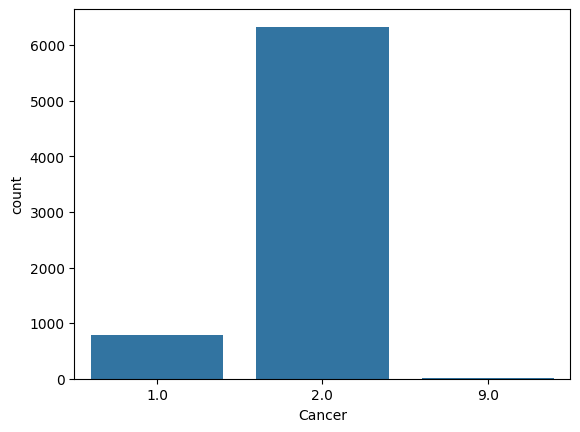

In [46]:
sns.countplot(mcq_pd, x='Cancer')
# plt.savefig('cancer_countplot.png', dpi=300, bbox_inches='tight')

## Combined Dataset Cleaning/EDA

In [47]:
# Data filters
df = df.filter(df['Age'] >= 20)
df = df.filter(df['Cancer'] != 9.0).filter(df['Cancer'] != 7.0)
df = df.fillna({'Alcohol/Day': 0})
df = df.na.drop()
df = df.filter(df['Alcohol/Day'] != 777.0).filter(df['Alcohol/Day'] != 999.0)
df = df.filter(df['Smokes?'] != 9.0).filter(df['Smokes?'] != 7.0)

cols79 = ['Congestive Heart Failure',
 'Coronary Heart Disease',
 'Heart Attack',
 'Stroke',
 'Thyroid']
for col in cols79:
    df = df.filter(df[col] != 9.0).filter(df[col] != 7.0)

df = df.withColumn("Gender", (df["Gender"] - 1).cast("int"))  # Male=0, Female=1

binary_cols = ["Smokes?", "Cancer", "Congestive Heart Failure", 
               "Coronary Heart Disease", "Heart Attack", "Stroke", "Thyroid"]

for col in binary_cols:
    df = df.withColumn(col, (df[col] == 1).cast("int"))




In [48]:
numeric_cols = ['SEQN', 'BMI', 'Height', 'Weight', 'Age']

for column in df.columns:
    if column not in numeric_cols:
        print(column)
        unique_vals = df.select(column).distinct().rdd.flatMap(lambda x: x).collect()
        print("   " + str(unique_vals))

Gender


   [1, 0]
Race


   [7.0, 1.0, 4.0, 3.0, 2.0, 6.0]
Smokes?


   [1, 0]
Alcohol/Day


   [8.0, 0.0, 7.0, 1.0, 4.0, 11.0, 14.0, 3.0, 2.0, 10.0, 6.0, 5.0, 15.0, 9.0, 12.0, 13.0, 18.0, 25.0, 20.0, 24.0, 16.0]
Cancer


...

   [1, 0]
Heart Attack


   [1, 0]
Stroke


   [1, 0]
Thyroid


[Stage 157:============================>                            (2 + 2) / 4]

   [1, 0]


In [49]:
df.describe().show()

[Stage 166:>                                                        (0 + 1) / 1]

+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+------------------------+----------------------+-------------------+-------------------+-------------------+
|summary|              SEQN|            Gender|              Age|              Race|            Weight|            Height|               BMI|            Smokes?|       Alcohol/Day|             Cancer|Congestive Heart Failure|Coronary Heart Disease|       Heart Attack|             Stroke|            Thyroid|
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+------------------------+----------------------+-------------------+-------------------+-------------------+
|  count|             24993|             24993|            24993|        

In [50]:
df.printSchema()

root
 |-- SEQN: double (nullable = true)
 |-- Gender: integer (nullable = true)
 |-- Age: double (nullable = true)
 |-- Race: double (nullable = true)
 |-- Weight: double (nullable = true)
 |-- Height: double (nullable = true)
 |-- BMI: double (nullable = true)
 |-- Smokes?: integer (nullable = true)
 |-- Alcohol/Day: double (nullable = false)
 |-- Cancer: integer (nullable = true)
 |-- Congestive Heart Failure: integer (nullable = true)
 |-- Coronary Heart Disease: integer (nullable = true)
 |-- Heart Attack: integer (nullable = true)
 |-- Stroke: integer (nullable = true)
 |-- Thyroid: integer (nullable = true)



In [51]:
df_pd = df.sample(fraction=0.25, seed=101).toPandas()

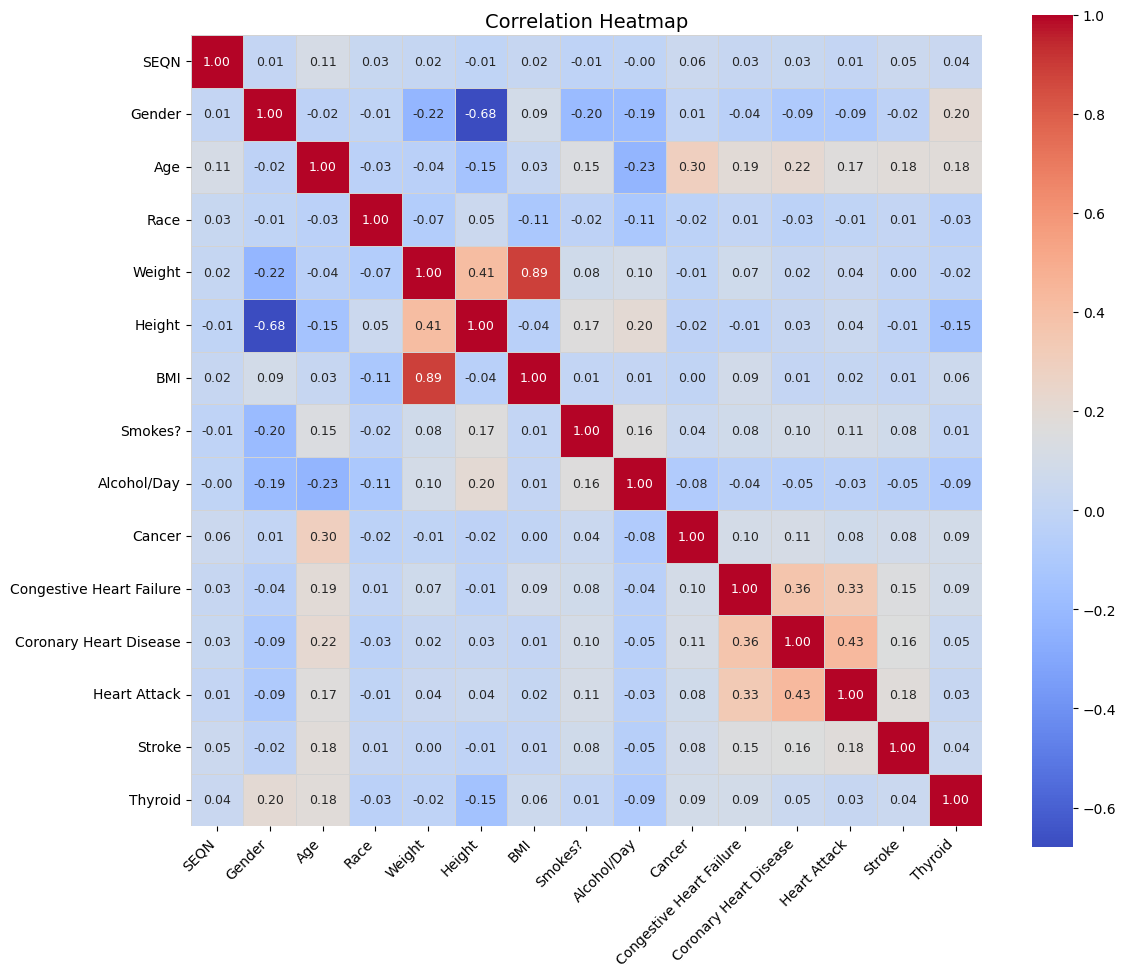

In [52]:
plt.figure(figsize=(12, 10)) 

sns.heatmap(
    df_pd.corr(),
    annot=True,
    fmt=".2f",               
    cmap="coolwarm",          
    cbar=True,
    square=True,             
    linewidths=0.5,            
    linecolor='lightgray',
    annot_kws={"size": 9}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
# plt.savefig('corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

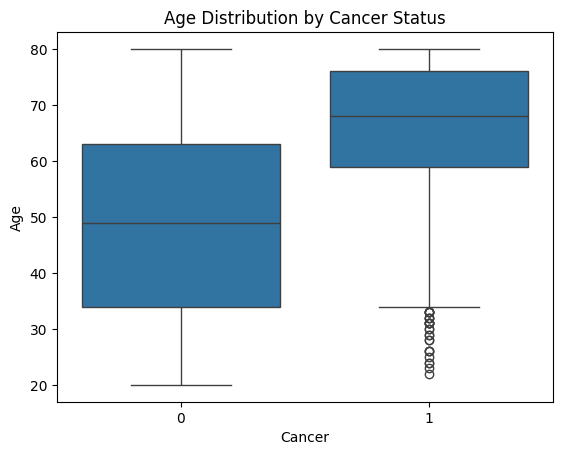

In [53]:
sns.boxplot(x='Cancer', y='Age', data=df_pd)
plt.title("Age Distribution by Cancer Status")
plt.show()


## Encoding and Normalizing

In [54]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

race_indexer = StringIndexer(inputCol="Race", outputCol="Race_index")
race_encoder = OneHotEncoder(inputCols=["Race_index"], outputCols=["Race_ohe"])
# df = race_indexer.fit(df).transform(df)
# df = race_encoder.fit(df).transform(df)

# df.select("Race", "Race_index", "Race_ohe").show(truncate=False)

In [55]:
df.columns

['SEQN',
 'Gender',
 'Age',
 'Race',
 'Weight',
 'Height',
 'BMI',
 'Smokes?',
 'Alcohol/Day',
 'Cancer',
 'Congestive Heart Failure',
 'Coronary Heart Disease',
 'Heart Attack',
 'Stroke',
 'Thyroid']

In [56]:
numerical_cols = ['Age', 'BMI', 'Alcohol/Day']
included_features = ['Gender',
 'Smokes?',
 'Congestive Heart Failure',
 'Coronary Heart Disease',
 'Heart Attack',
 'Stroke',
 'Thyroid',
 'Race_ohe']
from pyspark.ml.feature import StandardScaler, VectorAssembler

num_assembler = VectorAssembler(inputCols=numerical_cols, outputCol="num_features_unscaled")

scaler = StandardScaler(inputCol="num_features_unscaled", outputCol="num_features_scaled")

final_assembler = VectorAssembler(
    inputCols=["num_features_scaled"] + included_features,
    outputCol="features"
)


In [57]:
train_df, test_df = df.randomSplit([0.7, 0.3], seed=101)

In [58]:
# Resampling
from pyspark.sql import functions as F

major_df = train_df.filter(F.col("Cancer") == 0)
minor_df = train_df.filter(F.col("Cancer") == 1)

target_count = 6000

major_fraction = target_count / major_df.count()
major_df_resampled = major_df.sample(withReplacement=False, fraction=major_fraction, seed=42)

minor_repeat_factor = int(target_count / minor_df.count()) + 1
minor_df_resampled = minor_df
for _ in range(minor_repeat_factor - 1):
    minor_df_resampled = minor_df_resampled.union(minor_df)

minor_df_resampled = minor_df_resampled.limit(target_count)

train_balanced = major_df_resampled.union(minor_df_resampled)

train_balanced = train_balanced.orderBy(F.rand())

train_balanced.groupBy("Cancer").count().show()

[Stage 192:======================>                                  (2 + 2) / 5]

+------+-----+
|Cancer|count|
+------+-----+
|     0| 6071|
|     1| 6000|
+------+-----+



In [59]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[race_indexer, race_encoder, num_assembler, scaler, final_assembler])

pipeline_model = pipeline.fit(train_balanced)

train_prepped = pipeline_model.transform(train_balanced)
test_prepped = pipeline_model.transform(test_df)

train_prepped = train_prepped.select(['features', 'Cancer'])
test_prepped = test_prepped.select(['features', 'Cancer'])

In [60]:
test_prepped.show(5)

[Stage 232:>                                                        (0 + 1) / 1]

+--------------------+------+
|            features|Cancer|
+--------------------+------+
|(15,[0,1,3,10],[3...|     1|
|(15,[0,1,3,4,11],...|     0|
|(15,[0,1,2,3,5,9,...|     0|
|(15,[0,1,2,12],[2...|     0|
|(15,[0,1,2,3,4,10...|     0|
+--------------------+------+
only showing top 5 rows



In [69]:
test_prepped.show(5)

+--------------------+------+
|            features|Cancer|
+--------------------+------+
|(15,[0,1,3,10],[3...|     1|
|(15,[0,1,3,4,11],...|     0|
|(15,[0,1,2,3,5,9,...|     0|
|(15,[0,1,2,12],[2...|     0|
|(15,[0,1,2,3,4,10...|     0|
+--------------------+------+
only showing top 5 rows



In [61]:
test_prepped.show(5)

+--------------------+------+
|            features|Cancer|
+--------------------+------+
|(15,[0,1,3,10],[3...|     1|
|(15,[0,1,3,4,11],...|     0|
|(15,[0,1,2,3,5,9,...|     0|
|(15,[0,1,2,12],[2...|     0|
|(15,[0,1,2,3,4,10...|     0|
+--------------------+------+
only showing top 5 rows



In [70]:
train_prepped.show(5)

[Stage 332:==================================>                      (3 + 2) / 5]

+--------------------+------+
|            features|Cancer|
+--------------------+------+
|(15,[0,1,2,3,11],...|     1|
|(15,[0,1,3,9,14],...|     0|
|(15,[0,1,2,3,9,14...|     1|
|(15,[0,1,4,10],[4...|     1|
|(15,[0,1,3,12],[2...|     0|
+--------------------+------+
only showing top 5 rows



In [64]:
# Saving the pipeline, training, and testing sets
hdfs_loco = "hdfs://localhost:9000/user/jj/final_proj/"

train_prepped.write.mode("overwrite").parquet(hdfs_loco + "train.parquet")
test_prepped.write.mode("overwrite").parquet(hdfs_loco + "test.parquet")
pipeline_model.write().overwrite().save(hdfs_loco + "tabular_pipeline.parquet")